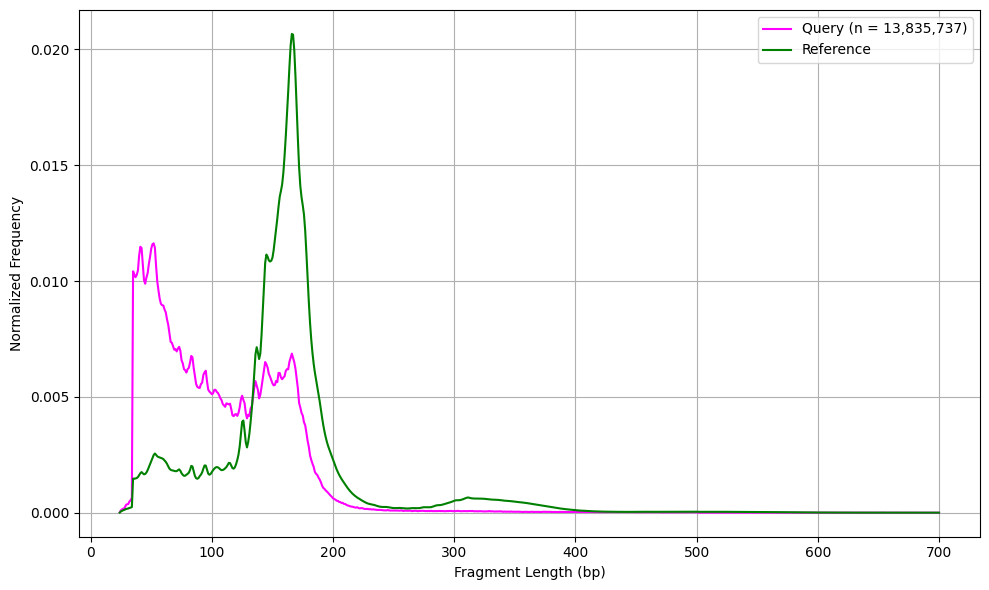

In [5]:
import gzip
import random
import matplotlib.pyplot as plt
from collections import Counter, defaultdict

def load_reference_hist(filename):
    ref_counts = {}
    total = 0
    with open(filename, "r") as f:
        for line in f:
            length, count = map(float, line.strip().split())
            ref_counts[int(length)] = count
            total += count
    for length in ref_counts:
        ref_counts[length] /= total
    return ref_counts

def load_query_bed(filename):
    fragments = defaultdict(list)
    with gzip.open(filename, "rt") as f:
        for line in f:
            if line.startswith("#") or not line.strip():
                continue
            parts = line.strip().split()
            start = int(parts[1])
            end = int(parts[2])
            length = end - start
            fragments[length].append((parts[0], start, end))
    return fragments

def normalize_counts(counts):
    total = sum(counts.values())
    return {k: v / total for k, v in counts.items()}

def count_lengths(fragments):
    lengths = [end - start for _, start, end in fragments]
    counts = Counter(lengths)
    return normalize_counts(counts), len(fragments)

# === MAIN ===
ref_dist = load_reference_hist("reference.hist")
query_fragments = load_query_bed("query.bed.gz")

# Flatten query fragments
original_flat = [frag for frag_list in query_fragments.values() for frag in frag_list]

# Get counts
query_counts, query_n = count_lengths(original_flat)

# Plot combined
plt.figure(figsize=(10, 6))

# Query (magenta line)
x_q = sorted(query_counts)
y_q = [query_counts[k] for k in x_q]
plt.plot(x_q, y_q, color='magenta', label=f"Query (n = {query_n:,})", linewidth=1.5)

# Reference (green line)
x_r = sorted(ref_dist)
y_r = [ref_dist[k] for k in x_r]
plt.plot(x_r, y_r, color='green', label="Reference", linewidth=1.5)

# Final plot styling
plt.xlabel("Fragment Length (bp)")
plt.ylabel("Normalized Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
